In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tamargurabanidze/dataset-fraud/sample_submission.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/test_identity.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/train_identity.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/test_transaction.csv
/kaggle/input/datasets/tamargurabanidze/dataset-fraud/train_transaction.csv
/kaggle/input/datasets/tamargurabanidze/house-prices/sample_submission.csv
/kaggle/input/datasets/tamargurabanidze/house-prices/data_description.txt
/kaggle/input/datasets/tamargurabanidze/house-prices/train.csv
/kaggle/input/datasets/tamargurabanidze/house-prices/test.csv


In [ ]:
# ==================================================
# CELL 1: IMPORTS & DAGSHUB SETUP
# ==================================================
!pip install mlflow dagshub xgboost -q

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder

DAGSHUB_USERNAME = "tgura23"
REPO_NAME        = "ieee-fraud-detection"

dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name=REPO_NAME,
    mlflow=True
)

mlflow.set_experiment("XGBoost_Training")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 78.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=770281c8-c9d7-4b07-a962-9ef2e99edcc2&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=12d441b8a098fb62a66209868b8e66742b0b5b06df43bbcc44f567ac7c262b72




Accessing as tgura23

Initialized MLflow to track repo "tgura23/ieee-fraud-detection"

Repository tgura23/ieee-fraud-detection initialized!

✅ DagsHub + MLflow კავშირი დამყარდა!


In [3]:
# ==================================================
# CELL 2: LOAD MODEL FROM MODEL REGISTRY
# ==================================================
# Model Registry-დან ვტვირთავთ "Production" stage-ს ან უახლეს ვერსიას

MODEL_NAME    = "XGBoost_Fraud_Pipeline"
MODEL_VERSION = "latest"  # ან კონკრეტული ვერსია, მაგ. "1"

# მიდგომა 1: stage-ით (Production/Staging/None)
try:
    model_uri = f"models:/{MODEL_NAME}/Production"
    pipeline  = mlflow.sklearn.load_model(model_uri)
    print(f"✅ მოდელი ჩაიტვირთა Production stage-დან: {model_uri}")
except Exception:
    # თუ Production stage არ არის — უახლეს ვერსიას ვიყენებთ
    print("⚠️  Production stage არ მოიძებნა — უახლეს ვერსიაზე გადასვლა...")
    client    = mlflow.MlflowClient()
    versions  = client.search_model_versions(f"name='{MODEL_NAME}'")
    latest_v  = max(versions, key=lambda v: int(v.version))
    model_uri = f"models:/{MODEL_NAME}/{latest_v.version}"
    pipeline  = mlflow.sklearn.load_model(model_uri)
    print(f"✅ მოდელი ჩაიტვირთა: {model_uri} (version={latest_v.version})")

print(f"Pipeline steps: {pipeline.steps}")

⚠️  Production stage არ მოიძებნა — უახლეს ვერსიაზე გადასვლა...


✅ მოდელი ჩაიტვირთა: models:/XGBoost_Fraud_Pipeline/1 (version=1)
Pipeline steps: [('imputer', SimpleImputer(strategy='median')), ('model', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=-1, num_parallel_tree=None, ...))]


In [ ]:
# ==================================================
# CELL 3: LOAD BEST FEATURES LIST FROM MLFLOW
# ==================================================
# Training-ის დროს შენახული xgb_best_features.json-ს ვტვირთავთ

client = mlflow.MlflowClient()


runs = client.search_runs(
    experiment_ids=mlflow.get_experiment_by_name("XGBoost_Training").experiment_id,
    filter_string="tags.mlflow.runName = 'XGB_13_BEST_FullData'",
    order_by=["metrics.mean_val_auc DESC"],
    max_results=1
)

if runs:
    best_run_id = runs[0].info.run_id
    print(f"Best Run ID: {best_run_id}")
    print(f"Val AUC:     {runs[0].data.metrics.get('mean_val_auc', 'N/A'):.4f}")
    
    # artifact ჩამოვწეროთ
    artifact_path = client.download_artifacts(best_run_id, "xgb_best_features.json")
    with open(artifact_path, 'r') as f:
        best_features = json.load(f)
    print(f"✅ Best features ჩაიტვირთა: {len(best_features)} feature")
else:
    raise RuntimeError("XGB_13_BEST_FullData run ვერ მოიძებნა! Training კოდი გაუშვი პირველად.")

Best Run ID: 7baed28136dd471bb94899b957022469
Val AUC:     0.9735


✅ Best features ჩაიტვირთა: 127 feature


In [ ]:
# ==================================================
# CELL 4: LOAD TEST DATA
# ==================================================
base_path = '/kaggle/input/datasets/tamargurabanidze/dataset-fraud/'

test_trans = pd.read_csv(base_path + 'test_transaction.csv', low_memory=False)
test_ident = pd.read_csv(base_path + 'test_identity.csv',   low_memory=False)

test = test_trans.merge(test_ident, on='TransactionID', how='left')

print(f"Test shape:  {test.shape}")
print(f"სულ კოლონი: {test.shape[1]}")

# TransactionID შევინახოთ submission-ისთვის
transaction_ids = test['TransactionID'].copy()

del test_trans, test_ident


Test shape:  (506691, 433)
სულ კოლონი: 433
✅ Test data ჩაიტვირთა!


In [6]:
# ==================================================
# CELL 5: PREPROCESSING (იგივე, რაც Training-ში)
# ==================================================
# IMPORTANT: test set-ზე ზუსტად იგივე ოპერაციები უნდა ჩავატაროთ!

df = test.copy()

# --- 1. 70%+ NaN კოლონების წაშლა (train-ის ზღვარი) ---
# train-ის NaN threshold-ს ვიყენებთ — test-ის NaN-ს ვერ გამოვიყენებთ!
# best_features სიაში მხოლოდ გადარჩენილი კოლონებია — ეს მოიცავს ფილტრს

# --- 2. კატეგორიული NaN → 'Unknown' ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
print(f"[2] Cat NaN → 'Unknown': {len(cat_cols)} კოლონი")

# --- 3. რიცხვითი NaN → 0 (Pipeline-ში SimpleImputer გაუმკლავდება median-ით) ---
# Pipeline-ის პირველი step არის SimpleImputer(strategy='median')
# ამიტომ NaN-ს ვტოვებთ — Imputer-ი თვითონ შეავსებს
print(f"[3] NaN-ები Pipeline-ის Imputer-ს დარჩება")

print(f"\nTest shape after basic cleaning: {df.shape}")

[2] Cat NaN → 'Unknown': 31 კოლონი
[3] NaN-ები Pipeline-ის Imputer-ს დარჩება

Test shape after basic cleaning: (506691, 433)


In [ ]:
# ==================================================
# CELL 6: FEATURE ENGINEERING (იგივე, რაც Training-ში)
# ==================================================

# --- 1. TransactionAmt ---
df['TransactionAmt_log']     = np.log1p(df['TransactionAmt'])
df['TransactionAmt_decimal'] = df['TransactionAmt'] % 1
df['TransactionAmt_isround'] = (df['TransactionAmt'] % 1 == 0).astype(int)

# --- 2. დროის feature-ები ---
df['Transaction_hour']      = (df['TransactionDT'] // 3600) % 24
df['Transaction_day']       = (df['TransactionDT'] // (3600 * 24)) % 7
df['Transaction_week']      = (df['TransactionDT'] // (3600 * 24 * 7)) % 4
df['Is_night_fraud_hour']   = df['Transaction_hour'].between(5, 10).astype(int)

# --- 3. card1 Frequency + Fraud Rate Encoding ---
# IMPORTANT: test-ის frequency ვიყენებთ test-ისთვის (train-ის freq ვერ გვაქვს)
# სწორი მიდგომა: train+test კომბინირებული freq, ან test-ის freq
card1_freq = df['card1'].value_counts()
df['card1_freq']       = df['card1'].map(card1_freq)
# Fraud rate: test-ს isFraud არ აქვს — 0-ს ვავსებთ (Imputer გაუმკლავდება)
df['card1_fraud_rate'] = 0.0  # test-ისთვის უცნობია — 0 placeholder

# --- 4. card2, card5 Frequency ---
for col in ['card2', 'card5']:
    freq = df[col].value_counts()
    df[f'{col}_freq'] = df[col].map(freq)

# --- 5. Email domain flag ---
high_fraud_domains = ['protonmail.com', 'mail.com', 'outlook.es', 'aim.com']
df['P_email_is_high_fraud'] = df['P_emaildomain'].isin(high_fraud_domains).astype(int)

# --- 6. კომბინირებული features ---
df['card1_addr1']      = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
card1_addr1_freq       = df['card1_addr1'].value_counts()
df['card1_addr1_freq'] = df['card1_addr1'].map(card1_addr1_freq)
df = df.drop(columns=['card1_addr1'])

df['card1_email']      = df['card1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
card1_email_freq       = df['card1_email'].value_counts()
df['card1_email_freq'] = df['card1_email'].map(card1_email_freq)
df = df.drop(columns=['card1_email'])

# --- 7. Label Encoding კატეგორიულებისთვის ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Feature Engineering დასრულდა. Shape: {df.shape}")


Feature Engineering დასრულდა. Shape: (506691, 447)
✅ Test სვეტები მზადაა!


In [8]:
# ==================================================
# CELL 7: SELECT FEATURES & VALIDATE
# ==================================================

# შევამოწმოთ რომელი best_features კოლონები არ გვაქვს test-ში
missing_in_test = [f for f in best_features if f not in df.columns]
if missing_in_test:
    print(f"⚠️  Test-ში მissing features ({len(missing_in_test)}):")
    for f in missing_in_test:
        print(f"   - {f}")
    # მissing კოლონები 0-ით შევავსოთ
    for f in missing_in_test:
        df[f] = 0
    print("   → 0-ით შეივსო")
else:
    print("✅ ყველა best_feature მოიძებნა test-ში!")

# X_test-ის გამოყოფა — იგივე კოლონების თანმიმდევრობა!
X_test = df[best_features]

print(f"\nX_test shape:    {X_test.shape}")
print(f"Features count:  {len(best_features)}")
print(f"Remaining NaN:   {X_test.isnull().sum().sum():,} (Pipeline-ი შეავსებს)")

✅ ყველა best_feature მოიძებნა test-ში!

X_test shape:    (506691, 127)
Features count:  127
Remaining NaN:   2,930,678 (Pipeline-ი შეავსებს)


In [9]:
# ==================================================
# CELL 8: PREDICT WITH REGISTRY MODEL
# ==================================================

with mlflow.start_run(run_name="XGBoost_Inference_TestSet"):

    # predict_proba — fraud-ის ალბათობა (კლასი 1)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    # ბინარული პროგნოზი (threshold=0.5)
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)

    # სტატისტიკა
    fraud_count    = y_pred_binary.sum()
    fraud_rate     = y_pred_binary.mean()
    mean_prob      = y_pred_proba.mean()
    high_conf      = (y_pred_proba >= 0.8).sum()

    print(f"სულ test სტრიქონი:        {len(y_pred_proba):,}")
    print(f"Predicted Fraud (>=0.5):  {fraud_count:,} ({fraud_rate:.2%})")
    print(f"Mean Fraud Probability:   {mean_prob:.4f}")
    print(f"High Confidence (>=0.8):  {high_conf:,} ({high_conf/len(y_pred_proba):.2%})")

    # MLflow ლოგვა
    mlflow.log_param("model_uri",       model_uri)
    mlflow.log_param("model_name",      MODEL_NAME)
    mlflow.log_param("n_features",      len(best_features))
    mlflow.log_metric("test_samples",   len(y_pred_proba))
    mlflow.log_metric("predicted_fraud_count", int(fraud_count))
    mlflow.log_metric("predicted_fraud_rate",  float(fraud_rate))
    mlflow.log_metric("mean_fraud_probability", float(mean_prob))

print("\n✅ Inference დასრულდა!")

სულ test სტრიქონი:        506,691
Predicted Fraud (>=0.5):  260 (0.05%)
Mean Fraud Probability:   0.0012
High Confidence (>=0.8):  38 (0.01%)
🏃 View run XGBoost_Inference_TestSet at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/2ace9ea7db484938bc68fb7d0c8ddb3e
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0

✅ Inference დასრულდა!


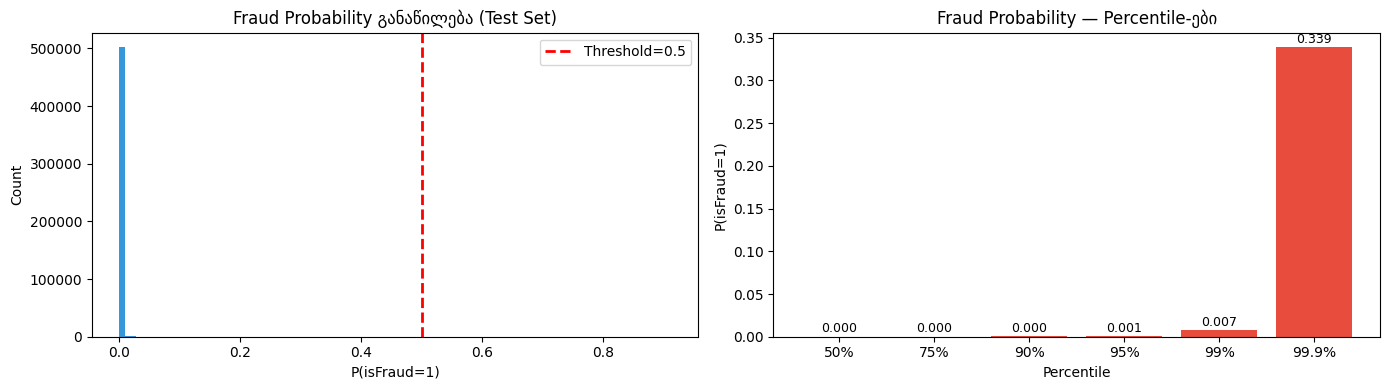

Fraud Probability სტატისტიკა:
count    5.066910e+05
mean     1.236698e-03
std      1.989772e-02
min      2.534691e-10
25%      3.738302e-06
50%      1.914583e-05
75%      8.397990e-05
max      9.121901e-01
dtype: float64


In [10]:
# ==================================================
# CELL 9: PROBABILITY DISTRIBUTION VISUALIZATION
# ==================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# პროგნოზის ალბათობების განაწილება
axes[0].hist(y_pred_proba, bins=100, color='#3498db', edgecolor='none')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[0].set_title('Fraud Probability განაწილება (Test Set)')
axes[0].set_xlabel('P(isFraud=1)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ალბათობების percentile-ები
percentiles = [50, 75, 90, 95, 99, 99.9]
pct_values  = np.percentile(y_pred_proba, percentiles)
axes[1].bar([str(p)+'%' for p in percentiles], pct_values, color='#e74c3c')
axes[1].set_title('Fraud Probability — Percentile-ები')
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('P(isFraud=1)')
for i, v in enumerate(pct_values):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Fraud Probability სტატისტიკა:")
print(pd.Series(y_pred_proba).describe())

In [ ]:
# ==================================================
# CELL 10: CREATE KAGGLE SUBMISSION FILE
# ==================================================

submission = pd.DataFrame({
    'TransactionID': transaction_ids,
    'isFraud':       y_pred_proba  # Kaggle-ი probability-ს ელის, არა binary label-ს
})

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)


print(f"\nShape:     {submission.shape}")
print(f"Columns:   {submission.columns.tolist()}")
print(f"\nპირველი 5 სტრიქონი:")
print(submission.head())

# MLflow-ში ავტვირთოთ submission-ც
with mlflow.start_run(run_name="XGBoost_Submission_Log"):
    mlflow.log_artifact(submission_path)
    mlflow.log_metric("submission_rows",      len(submission))
    mlflow.log_metric("submission_fraud_mean", float(submission['isFraud'].mean()))
    mlflow.log_param("submission_file",        submission_path)
    print(f"\n✅ Submission MLflow-ში დალოგილია!")

✅ Submission ფაილი შენახულია!

Shape:     (506691, 2)
Columns:   ['TransactionID', 'isFraud']

პირველი 5 სტრიქონი:
   TransactionID       isFraud
0        3663549  1.489077e-06
1        3663550  8.087626e-07
2        3663551  5.244623e-08
3        3663552  3.338539e-05
4        3663553  4.653655e-06

✅ Submission MLflow-ში დალოგილია!
🏃 View run XGBoost_Submission_Log at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0/runs/c4f2f549d0ac4d77a3340a5ffc7832ac
🧪 View experiment at: https://dagshub.com/tgura23/ieee-fraud-detection.mlflow/#/experiments/0


In [ ]:
# ==================================================
# CELL 11: VALIDATE SUBMISSION FORMAT
# ==================================================


errors = []

expected_cols = ['TransactionID', 'isFraud']
if list(submission.columns) != expected_cols:
    errors.append(f" კოლონები არასწორია: {submission.columns.tolist()}")
else:
    print(" კოლონების სახელები სწორია")


print(f"სტრიქონები: {len(submission):,}")


nan_count = submission.isnull().sum().sum()
if nan_count > 0:
    errors.append(f" NaN-ები submission-ში: {nan_count}")
else:
    print(" NaN-ები არ არის")

if submission['isFraud'].between(0, 1).all():
    print(f" isFraud range: [{submission['isFraud'].min():.4f}, {submission['isFraud'].max():.4f}]")
else:
    errors.append(" isFraud მნიშვნელობები [0,1]-ს გარეთ!")


if submission['TransactionID'].nunique() == len(submission):
    print(" TransactionID-ები უნიკალურია")
else:
    errors.append(" TransactionID-ების დუბლიკატები!")

if errors:
    print("\n".join(errors))
